# Index Module

In [1]:
import datetime as dt
import os
import numpy as np
import pandas as pd

from modules.index.formatters import create_col_from_emo
from modules.index.visualisation import plot_ei_topic
from modules.index.calculate import ei, epi, ei_topic, epi_topic
from constants import plutchik, path

In [2]:
# Pandas max columns
pd.set_option("display.max_columns", None)

## Load Data

In [3]:
df_videos = pd.read_parquet(os.path.join(path, "videos_full_with_topics.parquet"))
df_commentThreads = pd.read_parquet(os.path.join(path, "commentThreads_full_with_topics.parquet"))
df_commentThreadsReplies = pd.read_parquet(os.path.join(path, "commentThreadsReplies_full_with_topics.parquet"))

In [4]:
df_videos_2 = df_commentThreads[["publishedAt_ct", 'videoId'] + [i for i in df_commentThreads.columns if i.endswith("videos")]]
df_videos_2.drop_duplicates(subset=['videoId', 'entity_videos', 'topic_videos', 'emotion_videos'], inplace=True)
df_videos_2['publishedAt'] = pd.to_datetime(df_videos_2['publishedAt_ct']).dt.date
df_videos_2.drop(columns=['publishedAt_ct', 'publishedAt_videos'], inplace=True)
df_videos_2 = df_videos_2[(df_videos_2['publishedAt']>=dt.date(2025, 3, 19)) & (df_videos_2['publishedAt']<=dt.date(2025, 4, 20))]
df_videos_2.columns = [i.replace("_videos", "") for i in df_videos_2.columns]
# find common columns between df_videos and df_videos_2
common_cols = df_videos.columns.intersection(df_videos_2.columns)
# lowercase topic
df_videos_2['topic'] = df_videos_2['topic'].str.lower()
df_videos_2['topic'] = df_videos_2['topic'].str.replace("'s", "")
df_videos_2['topic'] = df_videos_2['topic'].str.replace('-', ' ')
df_videos_2 = df_videos_2[common_cols]
df_videos_2 = pd.merge(
    df_videos_2,
    df_videos[['videoId', 'topic', 'BERTopic', 'topic_level_0', 'topic_level_1', 'topic_level_2', 'topic_level_3', 'topic_level_4']], 
    on=['videoId', 'topic'], 
    how='left'
)

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_49666/1194183663.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_videos_2.drop_duplicates(subset=['videoId', 'entity_videos', 'topic_videos', 'emotion_videos'], inplace=True)
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_49666/1194183663.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_videos_2['publishedAt'] = pd.to_datetime(df_videos_2['publishedAt_ct']).dt.date
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_49666/1194183663.py:4: SettingWithCopyWarning: 
A value is

In [5]:
df_videos = pd.concat([df_videos, df_videos_2], ignore_index=True, axis=0)

In [6]:
# Rename columns
df_videos = df_videos.rename(columns={"publishedAt": "date"})
df_commentThreads = df_commentThreads.rename(columns={"publishedAt_ct": "date"})
df_commentThreadsReplies = df_commentThreadsReplies.rename(columns={"publishedAt_ctr": "date"})

# Format dates
df_videos["date"] = pd.to_datetime(df_videos["date"]).dt.date
df_commentThreads["date"] = pd.to_datetime(df_commentThreads["date"]).dt.date
df_commentThreadsReplies["date"] = pd.to_datetime(df_commentThreadsReplies["date"]).dt.date

min_date = dt.date(2025, 1, 6)
max_date = dt.date(2025, 5, 31)
filter_date = dt.date(2025, 1, 13)
df_videos = df_videos[(df_videos["date"] <= max_date)]
df_commentThreads = df_commentThreads[(df_commentThreads["date"] <= max_date)]
df_commentThreadsReplies = df_commentThreadsReplies[(df_commentThreadsReplies["date"] <= max_date)]

In [7]:
# Subset columns
gpt_cols = ["entity", "emotion", "topic"]
topic_cols = ["BERTopic", "topic_level_0", "topic_level_1", "topic_level_2", "topic_level_3", "topic_level_4"]
df_videos_subset = df_videos[["date"] + gpt_cols + topic_cols]
df_commentThreads_subset = df_commentThreads[["date"] + gpt_cols + topic_cols]
df_commentThreadsReplies_subset = df_commentThreadsReplies[["date"] + gpt_cols + topic_cols]

# Concat
df_videos_subset['type'] = 'transcript'
df_commentThreads_subset['type'] = 'comment'
df_commentThreadsReplies_subset['type'] = 'reply'
df_transcripts = df_videos_subset
df_comments = pd.concat([df_commentThreads_subset, df_commentThreadsReplies_subset], axis=0)

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_49666/2366698928.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_videos_subset['type'] = 'transcript'
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_49666/2366698928.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_commentThreads_subset['type'] = 'comment'
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_49666/2366698928.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

### Emotions

In [8]:
# Convert emotions into columns
df_transcripts_emo = create_col_from_emo(df_transcripts, 'emotion')
df_comments_emo = create_col_from_emo(df_comments, 'emotion')

In [9]:
# Group by date and emotion
df_transcripts_emo_grouped = df_transcripts_emo.groupby(['date'])[plutchik].sum().reset_index()
df_comments_emo_grouped = df_comments_emo.groupby(['date'])[plutchik].sum().reset_index()

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from copy import deepcopy
from constants import topic_list

# Define emotion groups and their colors
emocols = [
    "date",
    "anger",
    "disgust",
    "fear",
    "sadness",
    "anticipation",
    "joy",
    "trust",
    "surprise",
]
emocolours = {
    "joy": "#023047",
    "trust": "#126782",
    "anticipation": "#219EBC",
    "surprise": "#58B4D1",
    "anger": "#B62B2B",
    "fear": "#D42929",
    "disgust": "#F04242",
    "sadness": "#FF8787",
}

# Define topic groups and their colors
topiccols = [
    'date',
    'Conspiracy and Historical Events',
    'Disaster and Resilience',
    'Disputes and Opinions',
    'Economic and Financial Matters',
    'Education and Knowledge',
    'Environmental and Infrastructure',
    'Health and Social Welfare',
    'Labor and Workforce',
    'Leadership and Governance',
    'Legal and Regulatory Framework',
    'Miscellaneous and Other',
    'Power and Influence Dynamics',
    'Psychological and Emotional Aspects',
    'Quality of Life and Standards',
    'Security and Conflict',
    'Social and Cultural Aspects',
    'Sports and Recreation',
    'Trust, Credibility, and Communication'
]
topiccolours = {
    'Conspiracy and Historical Events': '#B62B2B',
    'Disaster and Resilience': '#8ECAE6',
    'Disputes and Opinions': '#F04242',
    'Economic and Financial Matters': '#023047',
    'Education and Knowledge': '#219EBC',
    'Environmental and Infrastructure': '#38B000',
    'Health and Social Welfare': '#FFB703',
    'Labor and Workforce': '#F4A259',
    'Leadership and Governance': '#FB8500',
    'Legal and Regulatory Framework': '#8D99AE',
    'Miscellaneous and Other': '#6c757d',
    'Power and Influence Dynamics': '#126782',
    'Psychological and Emotional Aspects': '#A7C957',
    'Quality of Life and Standards': '#B5838D',
    'Security and Conflict': '#D42929',
    'Social and Cultural Aspects': '#FF8787',
    'Sports and Recreation': '#58B4D1',
    'Trust, Credibility, and Communication': '#219EBC',
}


def plot_stack100(
    data1: pd.DataFrame,
    data2: pd.DataFrame,
    datatype: str,
    titlestr: str,
    legend_cols: int = 8,
    legend_add_gap: float = 0.0,
):
    if datatype == "emotion":
        columns = emocols
        colours = emocolours

    if datatype == "topic":
        columns = topiccols
        colours = topiccolours

    df1 = deepcopy(data1)
    df2 = deepcopy(data2)
    df1 = df1[columns]
    df2 = df2[columns]

    # Set 'date' as index
    df1["date"] = pd.to_datetime(df1["date"], format="%Y-%m-%d")
    df1 = df1[df1["date"].dt.date >= filter_date]
    df1.set_index("date", inplace=True)
    df2["date"] = pd.to_datetime(df2["date"], format="%Y-%m-%d")
    df2 = df2[df2["date"].dt.date >= filter_date]
    df2.set_index("date", inplace=True)

    # Create common index
    common_idx = df1.index.intersection(df2.index).sort_values()

    df1 = df1.loc[common_idx]
    df2 = df2.loc[common_idx]

    plt.rcParams.update({"font.size": 18})

    # Create figure with two subplots (side by side)
    fig, (ax1, ax3) = plt.subplots(
        2, 1, figsize=(20, 9), sharex=True, gridspec_kw={"height_ratios": [1, 1]}
    )

    # Normalize values so each row sums to 1 (100% stacked)
    df1_normalized = df1.div(df1.sum(axis=1), axis=0) * 100
    df2_normalized = df2.div(df2.sum(axis=1), axis=0) * 100

    # Plot 100% stacked bar chart
    df1_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax1,
        width=0.8,
        color=[colours[col] for col in df1_normalized.columns],
    )
    df2_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax3,
        width=0.8,
        color=[colours[col] for col in df2_normalized.columns],
    )

    # Formatting
    ax1.set_xlabel("")
    ax3.set_xlabel("")
    ax1.set_ylabel("Content Creators")
    ax3.set_ylabel("Community")

    # Format x-axis dates as 'DD-Mon'
    week_start_dates = df2.index[
        df2.index.weekday == 0
    ]  # Get only the Monday dates in the dataset
    ax3.set_xticks(
        [df2.index.get_loc(date) for date in week_start_dates]
    )  # Set ticks only at those dates
    ax3.set_xticklabels(week_start_dates.strftime("%d-%b"))  # Format labels correctly

    # Clear top ticks (shared axis will show them on bottom only)
    ax1.tick_params(labelbottom=False)

    # Turn off legends for all ax
    ax1.get_legend().remove()
    ax3.get_legend().remove()

    # Add shared titles for groups
    ax1.set_title(titlestr, fontsize=20, pad=20, fontweight="bold")

    # Add a black box around hurricane periods
    hurricane_periods = [
        ("2024-09-24", "2024-09-27", "Hurricane Helene"),
        ("2024-10-05", "2024-10-10", "Hurricane Milton"),
    ]

    # Rotate x-axis labels
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

    # # Move legend outside
    plt.legend(
        title="",
        bbox_to_anchor=(0.95, -0.4 + legend_add_gap),
        ncol=legend_cols,
        loc="right",
        fontsize="18",
    )

    plt.tight_layout()

    # Show plot
    plt.show()


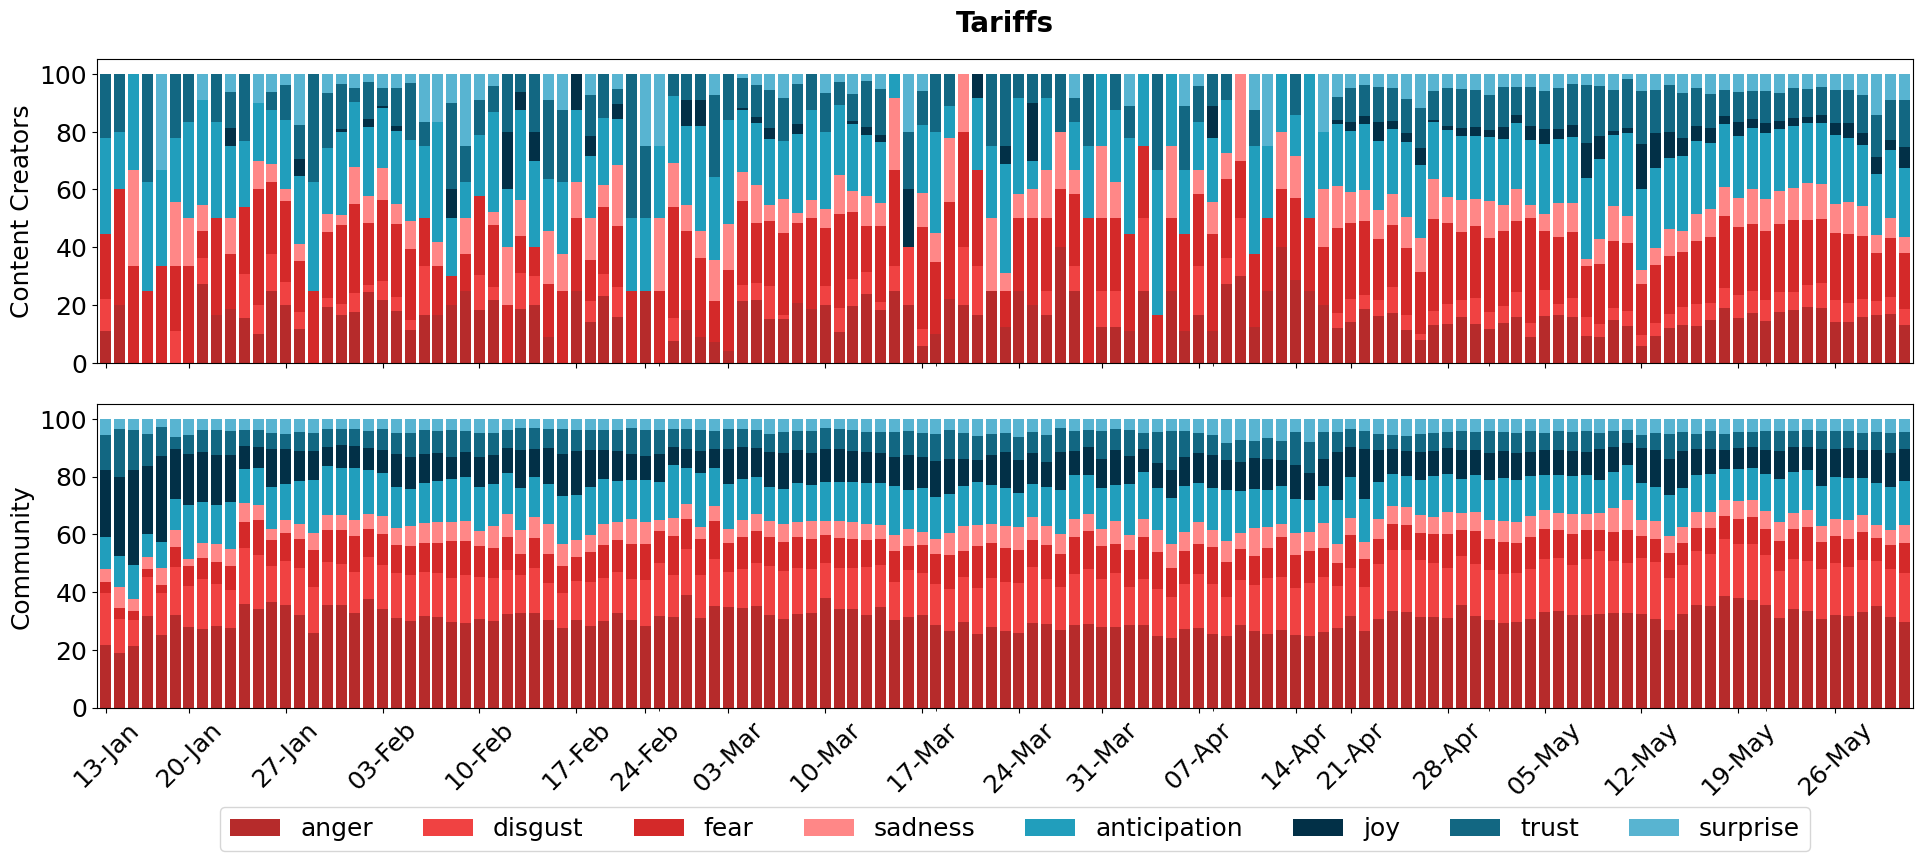

In [11]:
# Plot emotions
plot_stack100(
    # df_transcripts_emo_grouped[(df_transcripts_emo_grouped.date >= '2024-09-16') & (df_transcripts_emo_grouped.date <= '2024-10-17')],
    # df_comments_emo_grouped[(df_comments_emo_grouped.date >= '2024-09-16') & (df_comments_emo_grouped.date <= '2024-10-17')],
    df_transcripts_emo_grouped,
    df_comments_emo_grouped,
    datatype='emotion',
    titlestr='Tariffs',
    )

In [12]:
def plot_stack100(
    data1: pd.DataFrame,
    data2: pd.DataFrame,
    data3: pd.DataFrame,
    data4: pd.DataFrame,
    datatype: str,
    legend_cols: int = 8,
    legend_add_gap: float = 0.0,
):
    if datatype == "emotion":
        columns = emocols
        colours = emocolours

    if datatype == "topic":
        columns = topiccols
        colours = topiccolours

    df1 = deepcopy(data1)
    df2 = deepcopy(data2)
    df3 = deepcopy(data3)
    df4 = deepcopy(data4)
    df1 = df1[columns]
    df2 = df2[columns]
    df3 = df3[columns]
    df4 = df4[columns]

    # Set 'date' as index
    df1["date"] = pd.to_datetime(df1["date"], format="%Y-%m-%d")
    df1 = df1[df1["date"].dt.date >= filter_date]
    df1.set_index("date", inplace=True)
    df2["date"] = pd.to_datetime(df2["date"], format="%Y-%m-%d")
    df2 = df2[df2["date"].dt.date >= filter_date]
    df2.set_index("date", inplace=True)
    df3["date"] = pd.to_datetime(df3["date"], format="%Y-%m-%d")
    df3 = df3[df3["date"].dt.date >= filter_date]
    df3.set_index("date", inplace=True)
    df4["date"] = pd.to_datetime(df4["date"], format="%Y-%m-%d")
    df4 = df4[df4["date"].dt.date >= filter_date]
    df4.set_index("date", inplace=True)

    common_idx1 = df1.index.intersection(df2.index).sort_values()
    common_idx2 = df3.index.intersection(df4.index).sort_values()

    df1 = df1.loc[common_idx1]
    df2 = df2.loc[common_idx1]
    df3 = df3.loc[common_idx2]
    df4 = df4.loc[common_idx2]

    plt.rcParams.update({"font.size": 18})

    # Create figure with two subplots (side by side)
    fig, (ax1, ax3, ax5, ax7) = plt.subplots(
        1, 4, figsize=(20, 4), sharey=True, gridspec_kw={"wspace": 0.05}
    )

    # Normalize values so each row sums to 1 (100% stacked)
    df1_normalized = df1.div(df1.sum(axis=1), axis=0) * 100
    df2_normalized = df2.div(df2.sum(axis=1), axis=0) * 100
    df3_normalized = df3.div(df3.sum(axis=1), axis=0) * 100
    df4_normalized = df4.div(df4.sum(axis=1), axis=0) * 100

    # Plot 100% stacked bar chart
    df1_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax1,
        width=0.8,
        color=[colours[col] for col in df1_normalized.columns],
    )
    df2_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax3,
        width=0.8,
        color=[colours[col] for col in df2_normalized.columns],
    )
    df3_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax5,
        width=0.8,
        color=[colours[col] for col in df3_normalized.columns],
    )
    df4_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax7,
        width=0.8,
        color=[colours[col] for col in df4_normalized.columns],
    )

    # Formatting
    ax1.set_xlabel("")
    ax3.set_xlabel("")
    ax5.set_xlabel("")
    ax7.set_xlabel("")
    ax1.set_ylabel("Proportion (%)")

    # Format x-axis dates as 'DD-Mon'
    week_start_dates = df1.index[
        df1.index.weekday == 0
    ]  # Get only the Monday dates in the dataset
    ax1.set_xticks(
        [df1.index.get_loc(date) for date in week_start_dates]
    )  # Set ticks only at those dates
    ax1.set_xticklabels(week_start_dates.strftime("%d-%b"))  # Format labels correctly
    ax1.set_title("Content Creator")
    week_start_dates = df2.index[
        df2.index.weekday == 0
    ]  # Get only the Monday dates in the dataset
    ax3.set_xticks(
        [df2.index.get_loc(date) for date in week_start_dates]
    )  # Set ticks only at those dates
    ax3.set_xticklabels(week_start_dates.strftime("%d-%b"))  # Format labels correctly
    ax3.set_title("Community")
    week_start_dates = df3.index[
        df3.index.weekday == 0
    ]  # Get only the Monday dates in the dataset
    ax5.set_xticks(
        [df3.index.get_loc(date) for date in week_start_dates]
    )  # Set ticks only at those dates
    ax5.set_xticklabels(week_start_dates.strftime("%d-%b"))  # Format labels correctly
    ax5.set_title("Content Creator")
    week_start_dates = df4.index[
        df4.index.weekday == 0
    ]  # Get only the Monday dates in the dataset
    ax7.set_xticks(
        [df4.index.get_loc(date) for date in week_start_dates]
    )  # Set ticks only at those dates
    ax7.set_xticklabels(week_start_dates.strftime("%d-%b"))  # Format labels correctly
    ax7.set_title("Community")

    # Turn off legends for all ax
    ax1.get_legend().remove()
    ax3.get_legend().remove()
    ax5.get_legend().remove()
    ax7.get_legend().remove()

    # Add shared titles for groups
    fig.text(
        0.305, 0.97, "February 2025", ha="center", fontsize=20, fontweight="bold"
    )
    fig.text(
        0.715, 0.97, "May 2025", ha="center", fontsize=20, fontweight="bold"
    )

    # Add a black box around hurricane periods
    hurricane_periods = [
        ("2024-09-24", "2024-09-27", "Hurricane Helene"),
        ("2024-10-05", "2024-10-10", "Hurricane Milton"),
    ]

    # Rotate x-axis labels
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45)

    # Move legend outside
    plt.legend(
        title="",
        bbox_to_anchor=(-1.125, -0.4 + legend_add_gap),
        ncol=legend_cols,
        loc="center",
        fontsize="18",
    )

    plt.tight_layout()

    # Show plot
    plt.show()

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_49666/156610112.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


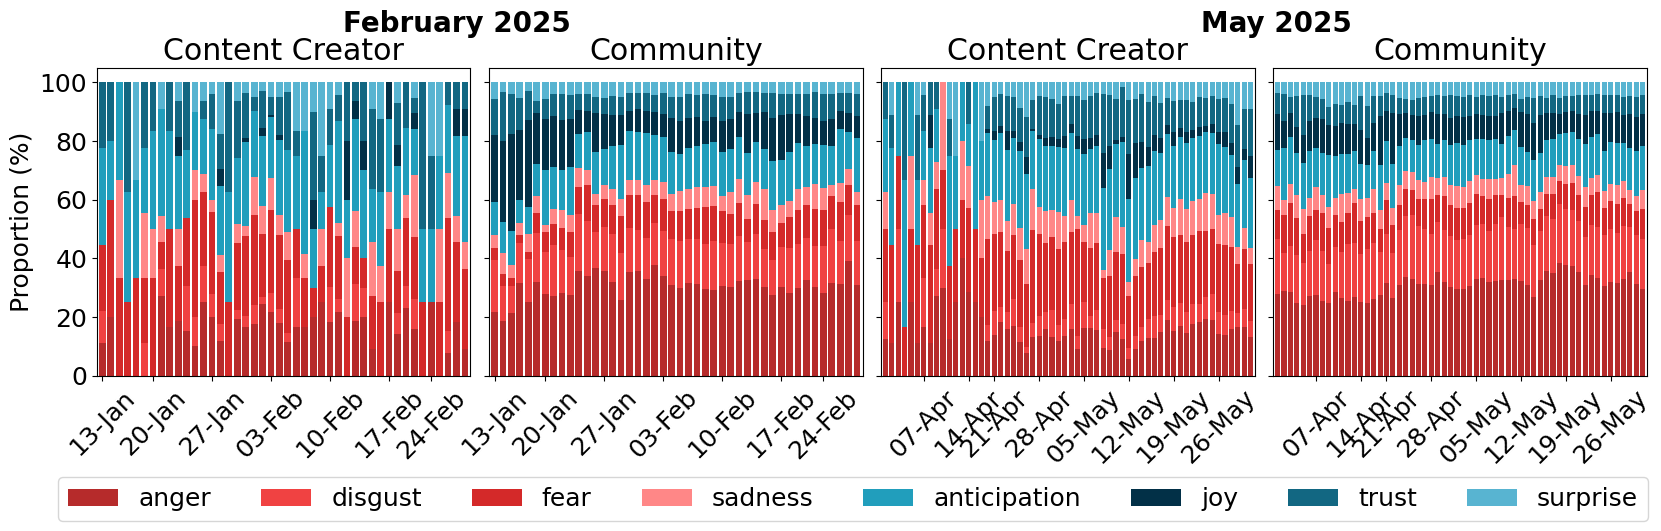

In [13]:
# Plot emotions
date_range1 = {"min": dt.date(2025, 1, 1), "max": dt.date(2025, 2, 28)}
date_range2 = {"min": dt.date(2025, 4, 1), "max": dt.date(2025, 5, 31)}
plot_stack100(
    df_transcripts_emo_grouped[(df_transcripts_emo_grouped.date >= date_range1["min"]) & (df_transcripts_emo_grouped.date <= date_range1["max"])],
    df_comments_emo_grouped[(df_comments_emo_grouped.date >= date_range1["min"]) & (df_comments_emo_grouped.date <= date_range1["max"])],
    df_transcripts_emo_grouped[(df_transcripts_emo_grouped.date >= date_range2["min"]) & (df_transcripts_emo_grouped.date <= date_range2["max"])],
    df_comments_emo_grouped[(df_comments_emo_grouped.date >= date_range2["min"]) & (df_comments_emo_grouped.date <= date_range2["max"])],
    datatype='emotion',
    )

## Emotion Polarity Index

In [14]:
df_transcripts_ei = ei(df_transcripts_emo_grouped, 'creator')
df_comments_ei = ei(df_comments_emo_grouped, 'community')

df_epi = epi(df_transcripts_ei, df_comments_ei)

In [15]:
df_epi.loc[(df_epi['ei_community']<0) & (df_epi['epi']>0), 'epi'] = -1 * df_epi['epi']

In [16]:
def epi_plot(
    df: pd.DataFrame,
):

    df1 = deepcopy(df)

    # Convert 'date' column to datetime format
    df1["date"] = pd.to_datetime(df1["date"], format="%Y-%m-%d")
    df1 = df1[df1["date"].dt.date >= filter_date]

    plt.rcParams.update({"font.size": 20})

    # Create figure with two subplots (side by side)
    fig, ax1 = plt.subplots(
        1, 1, figsize=(20, 10), sharey=True
    )

    # --- Graph ---
    ax1.plot(
        df1["date"],
        df1["ei_creator"],
        linestyle="--",
        color="b",
        label="Creator EI",
        linewidth=2,
    )
    ax1.plot(
        df1["date"],
        df1["ei_community"],
        linestyle="--",
        color="g",
        label="Community EI",
        linewidth=2,
    )
    ax1.plot(
        df1["date"], df1["epi"], linestyle="-", color="r", label="EPI", linewidth=4
    )
    # ax1.set_title("Hurricane Helene")
    ax1.set_ylim(-1, 1)

    # Annoucement Tariffs (20 Jan - 26 Jan)
    ax1.axvspan(
        pd.to_datetime("2025-01-20"),
        pd.to_datetime("2025-01-26"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-01-23"), 0.84, "Initial Tariff\nAnnouncements", color="black", ha="center")

    # # Announcement of Reciprocal Tariffs (10 Feb - 13 Feb)
    # ax1.axvspan(
    #     pd.to_datetime("2025-02-10"),
    #     pd.to_datetime("2025-02-13"),
    #     color="gray",
    #     alpha=0.3,
    # )
    # ax1.text(pd.to_datetime("2025-02-11"), 0.6, "Reciprocal Tariff\nAnnouncement", color="black", ha="center")

    # # Executive order on lumber and timber (24 Feb - 26 Feb)
    # ax1.axvspan(
    #     pd.to_datetime("2025-02-22"),
    #     pd.to_datetime("2025-02-26"),
    #     color="gray",
    #     alpha=0.3,
    # )
    # ax1.text(pd.to_datetime("2025-02-24"), 0.84, "Executive Order on\n Lumber and Timber", color="black", ha="center")

    # Imposition and Postponing of Tariffs (04 Mar - 06 Mar)
    ax1.axvspan(
        pd.to_datetime("2025-03-04"),
        pd.to_datetime("2025-03-06"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-03-04"), 0.6, "Tariffs\nPostponed", color="black", ha="center")

    # China retaliation (08 Mar - 12 Mar)
    # 200% Tariff Threat (12 Mar - 14 Mar)
    ax1.axvspan(
        pd.to_datetime("2025-03-10"),
        pd.to_datetime("2025-03-13"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-03-11"), 0.2, "China\nRetaliation\n& US Tariffs\nImposed", color="black", ha="center")

    # # Venezuela Tariff Threat (22 Mar - 26 Mar)
    # ax1.axvspan(
    #     pd.to_datetime("2025-03-22"),
    #     pd.to_datetime("2025-03-26"),
    #     color="gray",
    #     alpha=0.3,
    # )
    # ax1.text(pd.to_datetime("2025-03-24"), 0.6, "Venezuela\nTariff Threat", color="black", ha="center")

    # China Tariff Retaliation (2 Apr - 6 Apr)
    ax1.axvspan(
        pd.to_datetime("2025-04-02"),
        pd.to_datetime("2025-04-06"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-04-04"), 0.84, "Global Tariffs\n & China Retaliation", color="black", ha="center")

    # US China Tariff Threats (9 Apr - 11 Apr)
    ax1.axvspan(
        pd.to_datetime("2025-04-09"),
        pd.to_datetime("2025-04-12"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-04-12"), 0.6, "US-China\nTariff Threats", color="black", ha="center")

    # Tariff Relaxed (27 Apr - 04 May)
    ax1.axvspan(
        pd.to_datetime("2025-04-27"),
        pd.to_datetime("2025-05-04"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-04-30"), 0.55, "Tariffs\nRelaxed", color="black", ha="center")

    # Trade Deals and Tariff Rollbacks (05 May - 14 May)
    ax1.axvspan(
        pd.to_datetime("2025-05-05"),
        pd.to_datetime("2025-05-14"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-05-09"), 0.75, "Trade Deals\n & US-China\nTariff Rollbacks", color="black", ha="center")

    # Non-US Apple Tariff Threat (20 May - 25 May)
    ax1.axvspan(
        pd.to_datetime("2025-05-20"),
        pd.to_datetime("2025-05-25"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-05-22"), 0.45, "Non-US\nManufactured Apple\nTariff Threat", color="black", ha="center")

    # Formatting
    week_start_dates = (
        df1["date"].dt.to_period("W").drop_duplicates().dt.start_time
    )  # Get start of each week
    ax1.set_xticks(week_start_dates)  # Set ticks at these dates
    ax1.set_xticklabels(
        week_start_dates.dt.strftime("%d-%b")
    )  # Format labels correctly
    plt.xticks(rotation=360)  # Rotate x-ticks for better readability

    # Remove x-axis label
    ax1.set_ylabel("Index")

    # Combine legends from both graphs and place at the bottom outside the plot
    lines1, labels1 = ax1.get_legend_handles_labels()
    fig.legend(
        lines1,
        labels1,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.22),
        ncol=3,
        fontsize=20,
    )

    # Rotate x-axis labels
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # Adjust layout to ensure everything fits
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    # Show plot
    plt.show()

In [17]:
df_epi_copy = deepcopy(df_epi)
df_key_moments = df_epi_copy[
        (df_epi_copy['date'] >= pd.to_datetime("2025-01-20")) &
        (df_epi_copy['date'] <= pd.to_datetime("2025-01-26")) |

        # (df_epi_copy['date'] >= pd.to_datetime("2025-02-10")) &
        # (df_epi_copy['date'] <= pd.to_datetime("2025-02-13")) |

        # (df_epi_copy['date'] >= pd.to_datetime("2025-02-22")) &
        # (df_epi_copy['date'] <= pd.to_datetime("2025-02-26")) |

        (df_epi_copy['date'] >= pd.to_datetime("2025-03-04")) &
        (df_epi_copy['date'] <= pd.to_datetime("2025-03-06")) |

        (df_epi_copy['date'] >= pd.to_datetime("2025-03-10")) &
        (df_epi_copy['date'] <= pd.to_datetime("2025-03-13")) |

        # (df_epi_copy['date'] >= pd.to_datetime("2025-03-22")) &
        # (df_epi_copy['date'] <= pd.to_datetime("2025-03-26")) |

        (df_epi_copy['date'] >= pd.to_datetime("2025-04-02")) &
        (df_epi_copy['date'] <= pd.to_datetime("2025-04-06")) |

        (df_epi_copy['date'] >= pd.to_datetime("2025-04-09")) &
        (df_epi_copy['date'] <= pd.to_datetime("2025-04-12")) |

        (df_epi_copy['date'] >= pd.to_datetime("2025-04-27")) &
        (df_epi_copy['date'] <= pd.to_datetime("2025-05-04")) |

        (df_epi_copy['date'] >= pd.to_datetime("2025-05-05")) &
        (df_epi_copy['date'] <= pd.to_datetime("2025-05-14")) |

        (df_epi_copy['date'] >= pd.to_datetime("2025-05-20")) &
        (df_epi_copy['date'] <= pd.to_datetime("2025-05-25"))
]

df_not_key_moments = df_epi_copy[~df_epi_copy['date'].isin(df_key_moments['date'])]

In [18]:
# Calculate mean for key moments 2dp
print(np.round(np.mean(df_key_moments['epi']), 2))

# Calculate mean for non-key moments
print(np.round(np.mean(df_not_key_moments['epi']), 2))

# Calculate sd for key moments
print(np.round(np.std(df_key_moments['epi']), 2))

# Calculate sd for non-key moments
print(np.round(np.std(df_not_key_moments['epi']), 2))

-0.34
-0.41
0.27
0.25


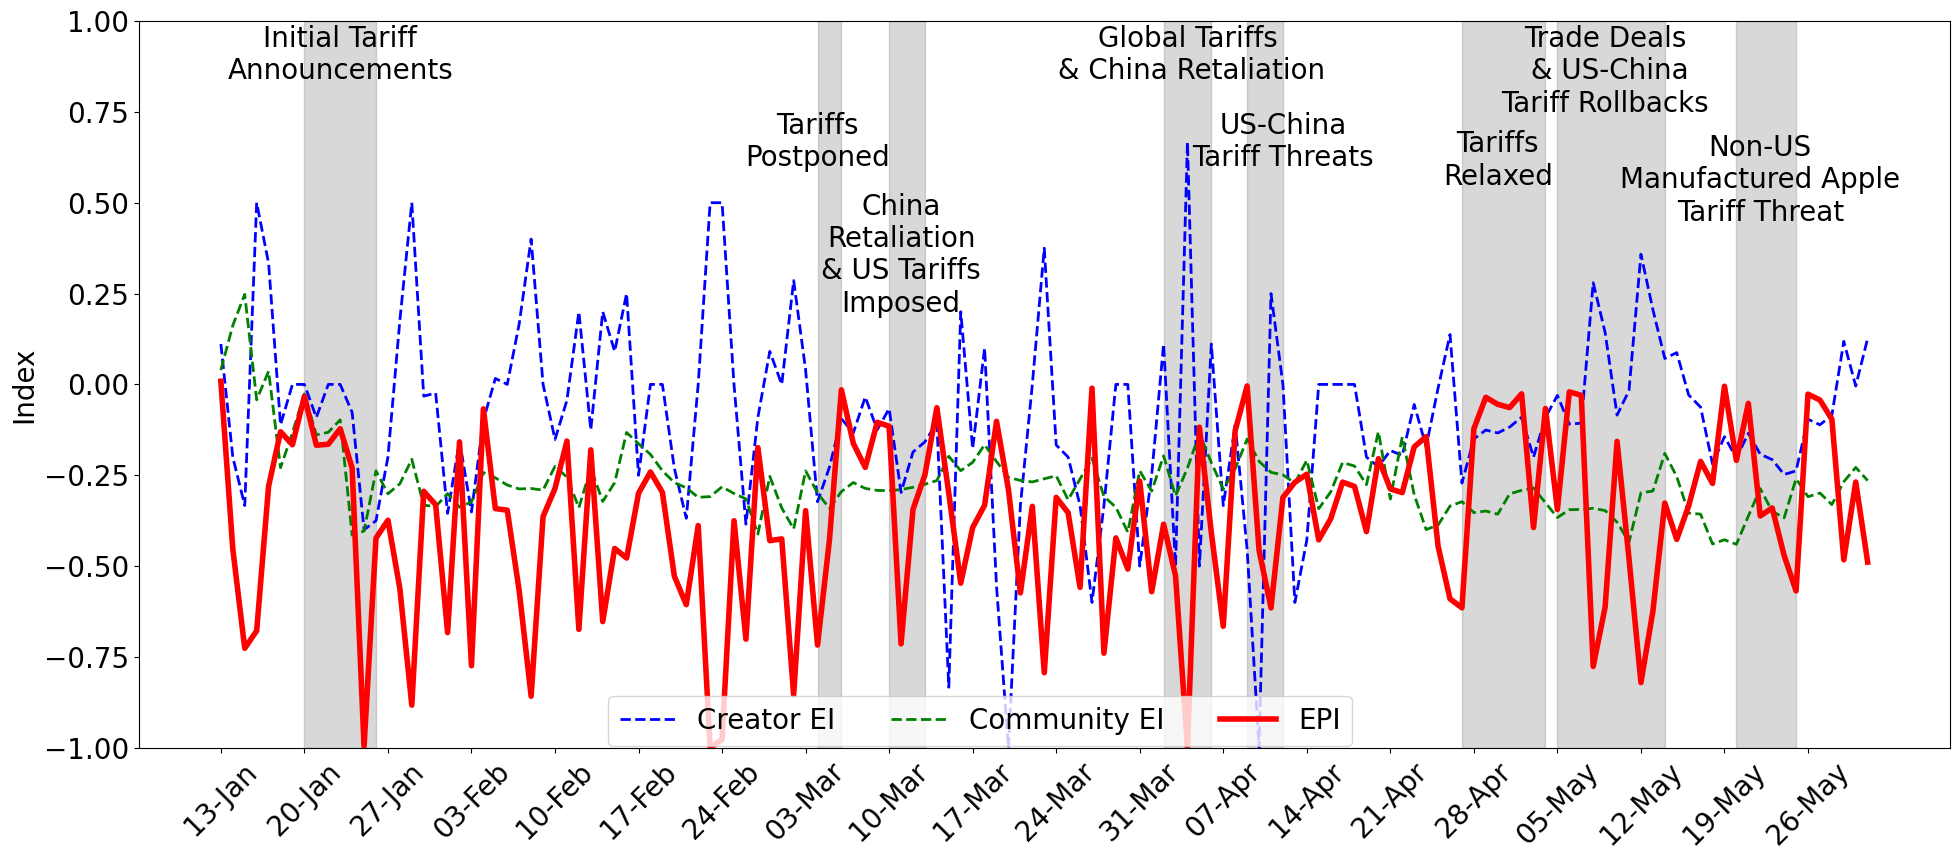

In [19]:
epi_plot(
    df_epi
)

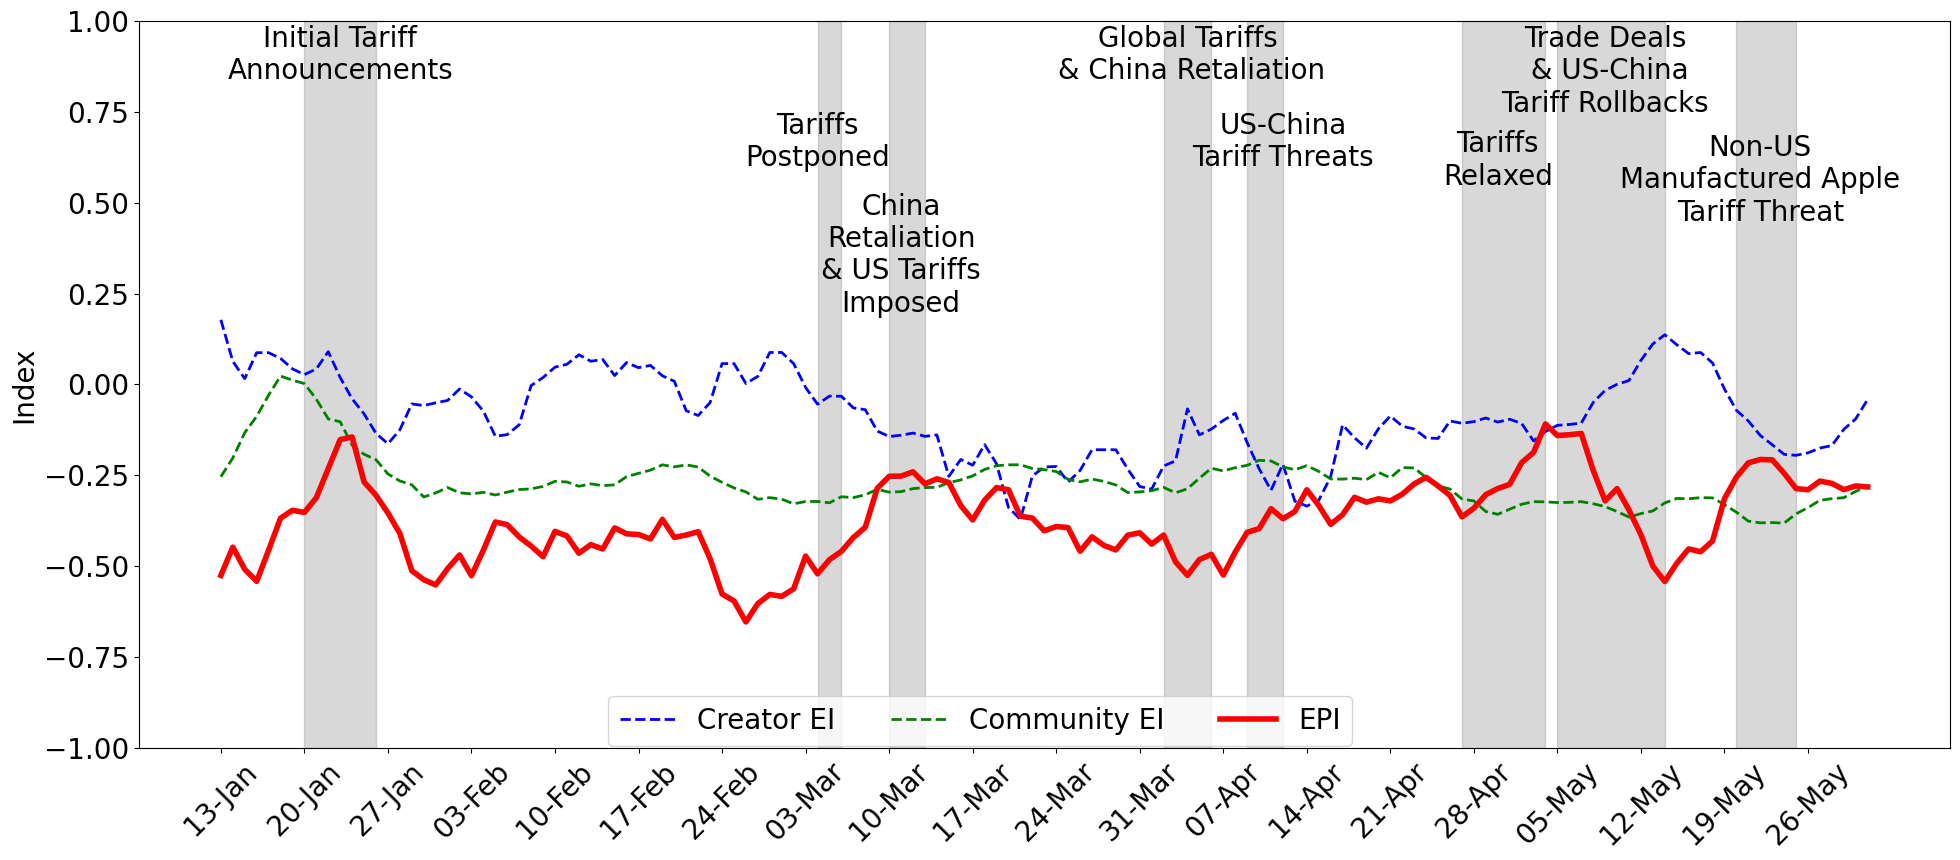

In [20]:
# Create rolling 3-day window averages for df_epi
df_epi_MA3 = df_epi.copy()
df_epi_MA3['ei_creator'] = df_epi['ei_creator'].rolling(window=7).mean()
df_epi_MA3['ei_community'] = df_epi['ei_community'].rolling(window=7).mean()
df_epi_MA3['epi'] = df_epi['epi'].rolling(window=7).mean()

epi_plot(
    df_epi_MA3
)

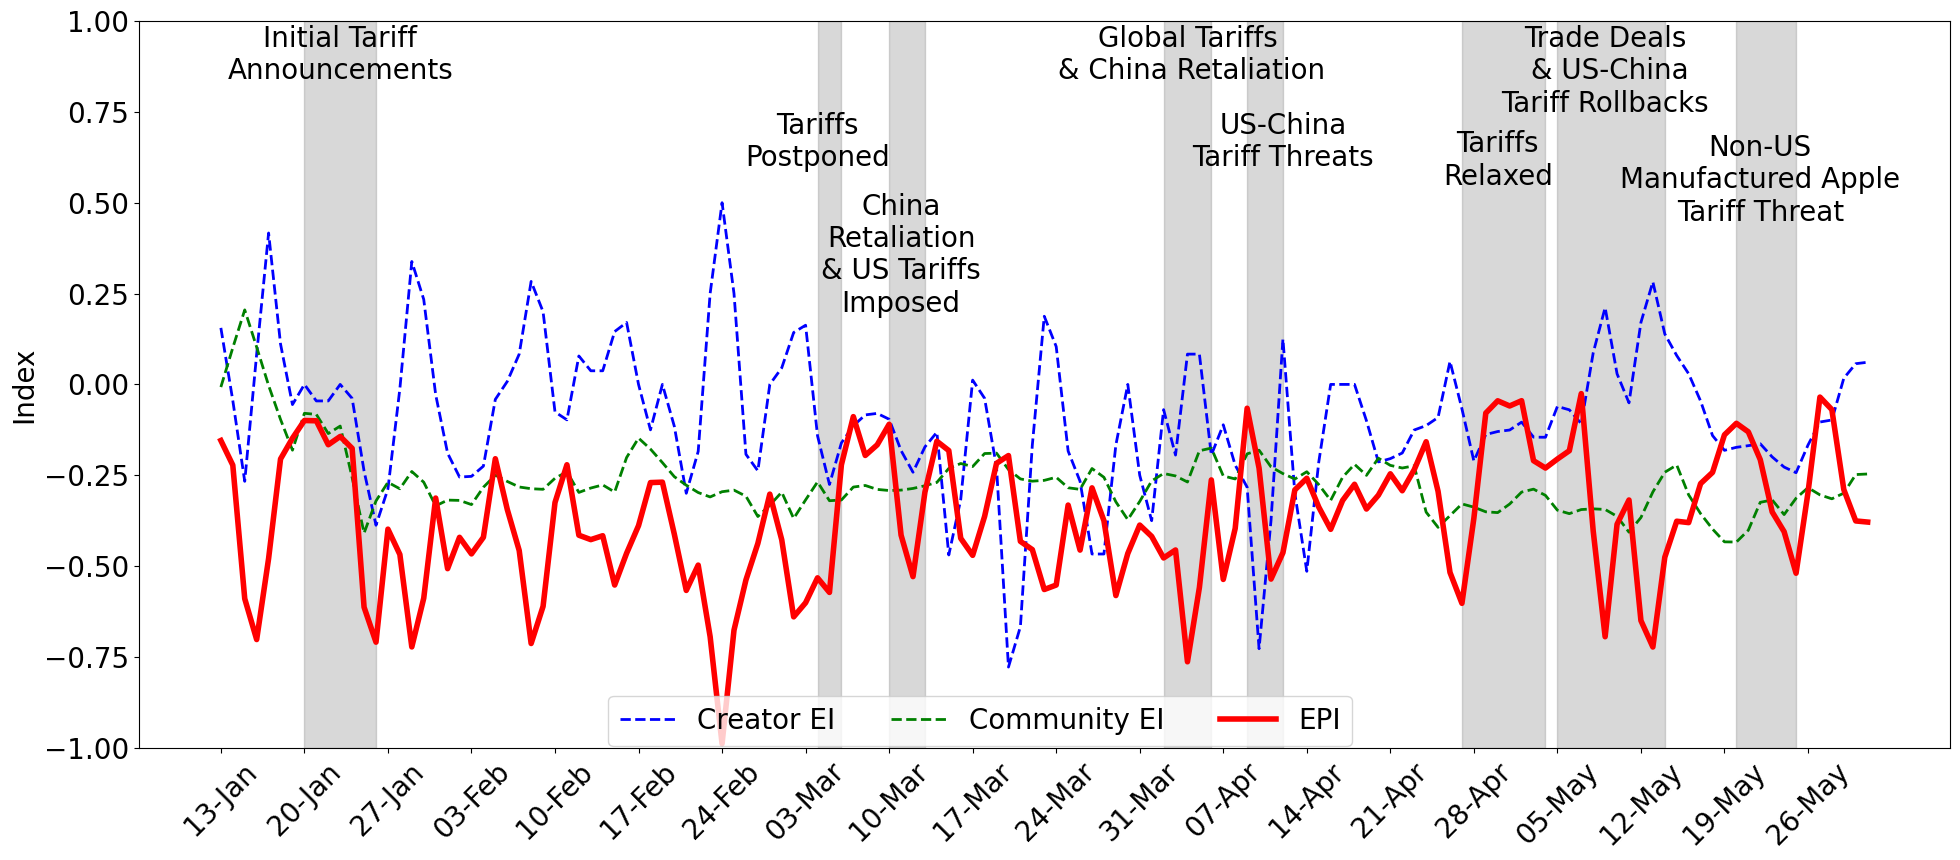

In [21]:
# Create rolling 2-day window averages for df_epi
df_epi_MA2 = df_epi.copy()
df_epi_MA2['ei_creator'] = df_epi['ei_creator'].rolling(window=2).mean()
df_epi_MA2['ei_community'] = df_epi['ei_community'].rolling(window=2).mean()
df_epi_MA2['epi'] = df_epi['epi'].rolling(window=2).mean()

epi_plot(
    df_epi_MA2
)

In [22]:
print("------\nTranscripts\n------")
for i in topic_cols:
    print(f"{i}: {len(df_transcripts_emo[i].unique())} unique values")
print("\n------\nComments & Replies\n------")
for i in topic_cols:
    print(f"{i}: {len(df_comments_emo[i].unique())} unique values")
print("\n------\nALL\n------")
for i in topic_cols:
    print(f"{i}: {len(set(list(df_comments_emo[i].unique())+list(df_transcripts_emo[i].unique())))} unique values")

------
Transcripts
------
BERTopic: 2655 unique values
topic_level_0: 19 unique values
topic_level_1: 35 unique values
topic_level_2: 71 unique values
topic_level_3: 186 unique values
topic_level_4: 656 unique values

------
Comments & Replies
------
BERTopic: 6126 unique values
topic_level_0: 19 unique values
topic_level_1: 35 unique values
topic_level_2: 77 unique values
topic_level_3: 208 unique values
topic_level_4: 898 unique values

------
ALL
------
BERTopic: 6126 unique values
topic_level_0: 19 unique values
topic_level_1: 35 unique values
topic_level_2: 77 unique values
topic_level_3: 208 unique values
topic_level_4: 898 unique values


In [23]:
topic_list_transcripts = [i for i in df_transcripts_emo['topic_level_0'].unique().tolist() if i]
topic_list_comments = [i for i in df_comments_emo['topic_level_0'].unique().tolist() if i]

In [24]:
# combine topic lists
topic_list = list(set(topic_list_transcripts) | set(topic_list_comments))

In [25]:
def plot_stack100_topics(
    data1: pd.DataFrame,
    data2: pd.DataFrame,
    data3: pd.DataFrame,
    data4: pd.DataFrame,
    legend_cols: int = 8,
    legend_add_gap: float = 0.0,
):
    columns = topiccols
    colours = topiccolours

    df1 = deepcopy(data1)
    df2 = deepcopy(data2)
    df3 = deepcopy(data3)
    df4 = deepcopy(data4)
    df1 = df1[columns]
    df2 = df2[columns]
    df3 = df3[columns]
    df4 = df4[columns]

    # Set 'date' as index
    df1["date"] = pd.to_datetime(df1["date"], format="%Y-%m-%d")
    df1 = df1[df1["date"].dt.date >= filter_date]
    df1.set_index("date", inplace=True)
    df2["date"] = pd.to_datetime(df2["date"], format="%Y-%m-%d")
    df2 = df2[df2["date"].dt.date >= filter_date]
    df2.set_index("date", inplace=True)
    df3["date"] = pd.to_datetime(df3["date"], format="%Y-%m-%d")
    df3 = df3[df3["date"].dt.date >= filter_date]
    df3.set_index("date", inplace=True)
    df4["date"] = pd.to_datetime(df4["date"], format="%Y-%m-%d")
    df4 = df4[df4["date"].dt.date >= filter_date]
    df4.set_index("date", inplace=True)

    common_idx1 = df1.index.intersection(df2.index).sort_values()
    common_idx2 = df3.index.intersection(df4.index).sort_values()

    df1 = df1.loc[common_idx1]
    df2 = df2.loc[common_idx1]
    df3 = df3.loc[common_idx2]
    df4 = df4.loc[common_idx2]

    plt.rcParams.update({"font.size": 18})

    # Create figure with two subplots (side by side)
    fig, (ax1, ax3, ax5, ax7) = plt.subplots(
        1, 4, figsize=(20, 4), sharey=True, gridspec_kw={"wspace": 0.05}
    )

    # Normalize values so each row sums to 1 (100% stacked)
    df1_normalized = df1.div(df1.sum(axis=1), axis=0) * 100
    df2_normalized = df2.div(df2.sum(axis=1), axis=0) * 100
    df3_normalized = df3.div(df3.sum(axis=1), axis=0) * 100
    df4_normalized = df4.div(df4.sum(axis=1), axis=0) * 100
    print(df1_normalized.columns)

    # Plot 100% stacked bar chart
    df1_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax1,
        width=0.8,
        color=[colours[col] for col in df1_normalized.columns.tolist()],
    )
    df2_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax3,
        width=0.8,
        color=[colours[col] for col in df2_normalized.columns],
    )
    df3_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax5,
        width=0.8,
        color=[colours[col] for col in df3_normalized.columns],
    )
    df4_normalized.plot(
        kind="bar",
        stacked=True,
        ax=ax7,
        width=0.8,
        color=[colours[col] for col in df4_normalized.columns],
    )

    # Formatting
    ax1.set_xlabel("")
    ax3.set_xlabel("")
    ax5.set_xlabel("")
    ax7.set_xlabel("")
    ax1.set_ylabel("Proportion (%)")

    # Format x-axis dates as 'DD-Mon'
    week_start_dates = df1.index[
        df1.index.weekday == 0
    ]  # Get only the Monday dates in the dataset
    ax1.set_xticks(
        [df1.index.get_loc(date) for date in week_start_dates]
    )  # Set ticks only at those dates
    ax1.set_xticklabels(week_start_dates.strftime("%d-%b"))  # Format labels correctly
    ax1.set_title("Content Creator")
    week_start_dates = df2.index[
        df2.index.weekday == 0
    ]  # Get only the Monday dates in the dataset
    ax3.set_xticks(
        [df2.index.get_loc(date) for date in week_start_dates]
    )  # Set ticks only at those dates
    ax3.set_xticklabels(week_start_dates.strftime("%d-%b"))  # Format labels correctly
    ax3.set_title("Community")
    week_start_dates = df3.index[
        df3.index.weekday == 0
    ]  # Get only the Monday dates in the dataset
    ax5.set_xticks(
        [df3.index.get_loc(date) for date in week_start_dates]
    )  # Set ticks only at those dates
    ax5.set_xticklabels(week_start_dates.strftime("%d-%b"))  # Format labels correctly
    ax5.set_title("Content Creator")
    week_start_dates = df4.index[
        df4.index.weekday == 0
    ]  # Get only the Monday dates in the dataset
    ax7.set_xticks(
        [df4.index.get_loc(date) for date in week_start_dates]
    )  # Set ticks only at those dates
    ax7.set_xticklabels(week_start_dates.strftime("%d-%b"))  # Format labels correctly
    ax7.set_title("Community")

    # Turn off legends for all ax
    ax1.get_legend().remove()
    ax3.get_legend().remove()
    ax5.get_legend().remove()
    ax7.get_legend().remove()

    # Add shared titles for groups
    fig.text(
        0.305, 0.97, "February 2025", ha="center", fontsize=20, fontweight="bold"
    )
    fig.text(
        0.715, 0.97, "May 2025", ha="center", fontsize=20, fontweight="bold"
    )

    # Add a black box around hurricane periods
    hurricane_periods = [
        ("2024-09-24", "2024-09-27", "Hurricane Helene"),
        ("2024-10-05", "2024-10-10", "Hurricane Milton"),
    ]

    # Rotate x-axis labels
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45)

    # Move legend outside
    plt.legend(
        title="",
        bbox_to_anchor=(-1.125, -0.4 + legend_add_gap),
        ncol=legend_cols,
        loc="center",
        fontsize="18",
    )

    plt.tight_layout()

    # Show plot
    plt.show()

In [26]:
# Plot topics
df_transcripts_topics = deepcopy(df_transcripts_emo)
df_comments_topics = deepcopy(df_comments_emo)

sorted_topic_list = sorted(topic_list)
for i in sorted_topic_list:
    if i:
        df_transcripts_topics[f"{i}"] = np.where(df_transcripts_topics[f"topic_level_0"]==i, 1, 0)
        df_comments_topics[f"{i}"] = np.where(df_comments_topics[f"topic_level_0"]==i, 1, 0)

df_transcripts_grouped_topics = df_transcripts_topics.groupby(['date'])[sorted_topic_list].sum().reset_index()
df_comments_grouped_topics = df_comments_topics.groupby(['date'])[sorted_topic_list].sum().reset_index()

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_49666/156610112.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


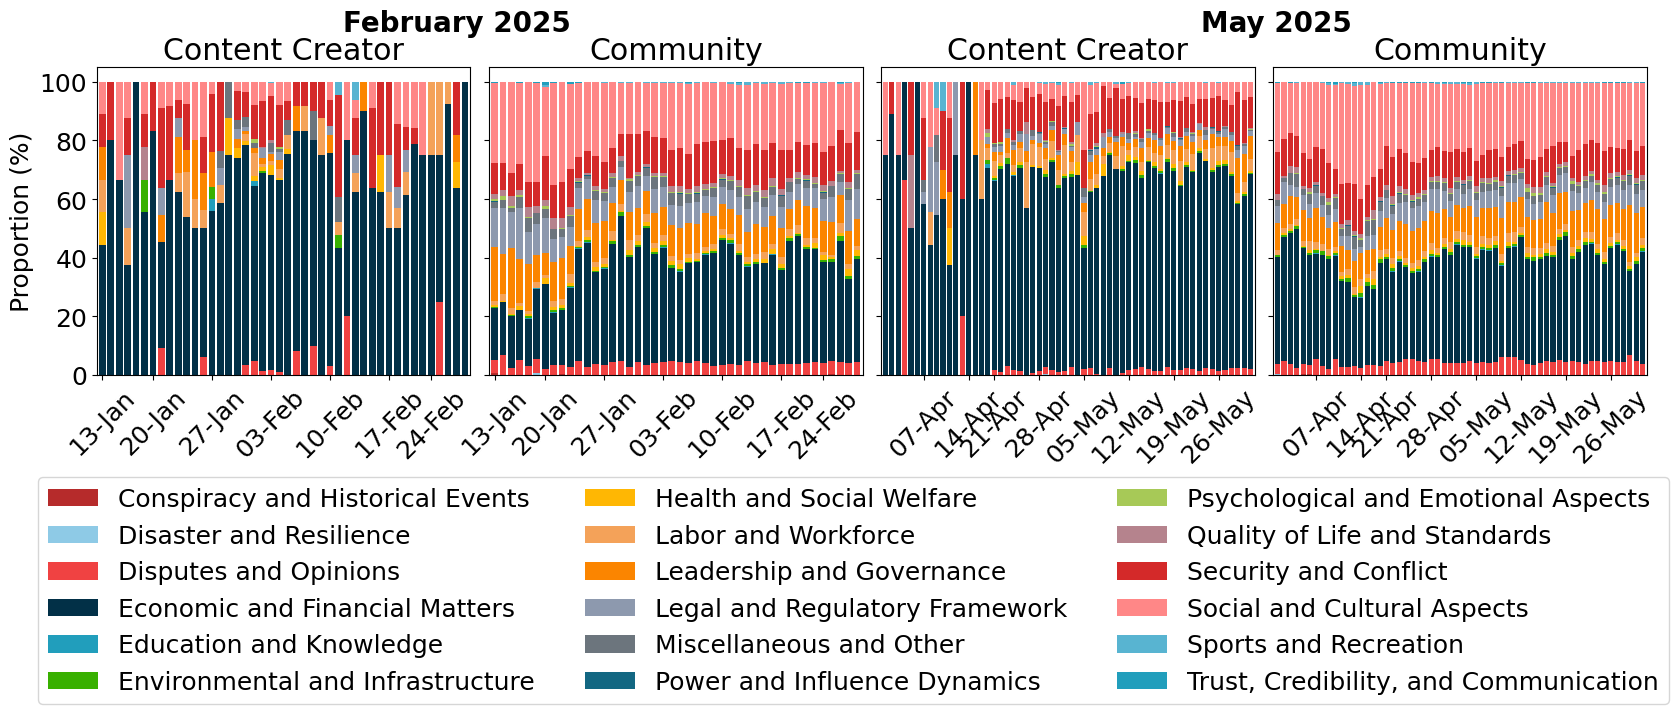

In [27]:
plot_stack100(
    df_transcripts_grouped_topics[(df_transcripts_grouped_topics.date >= date_range1["min"]) & (df_transcripts_grouped_topics.date <= date_range1["max"])],
    df_comments_grouped_topics[(df_comments_grouped_topics.date >= date_range1["min"]) & (df_comments_grouped_topics.date <= date_range1["max"])],
    df_transcripts_grouped_topics[(df_transcripts_grouped_topics.date >= date_range2["min"]) & (df_transcripts_grouped_topics.date <= date_range2["max"])],
    df_comments_grouped_topics[(df_comments_grouped_topics.date >= date_range2["min"]) & (df_comments_grouped_topics.date <= date_range2["max"])],
    datatype='topic',
    legend_cols=3,
    legend_add_gap=-0.3,
    )

In [28]:
# Get percentage of topics
df_transcripts_grouped_topics['total'] = df_transcripts_grouped_topics[topic_list].sum(axis=1)
df_comments_grouped_topics['total'] = df_comments_grouped_topics[topic_list].sum(axis=1)

for i in topic_list:
    df_transcripts_grouped_topics[f"{i}_percent"] = df_transcripts_grouped_topics[f"{i}"] / df_transcripts_grouped_topics['total']
    df_comments_grouped_topics[f"{i}_percent"] = df_comments_grouped_topics[f"{i}"] / df_comments_grouped_topics['total']

In [29]:
topic_percentages = {
    "Transcripts": {},
    "Comments": {},
    "Overall" : {},
}

for i in sorted_topic_list:
    topic_percentages["Transcripts"][i] = np.mean(df_transcripts_grouped_topics[f"{i}_percent"])*100
    topic_percentages["Comments"][i] = np.mean(df_comments_grouped_topics[f"{i}_percent"])*100
    topic_percentages["Overall"][i] = (topic_percentages["Transcripts"][i] + topic_percentages["Comments"][i])/2

pd.DataFrame(topic_percentages).map(lambda x: f"{x:.2f}%" if isinstance(x, (int, float, np.floating)) else x)

,Transcripts,Comments,Overall
Conspiracy and Historical Events,0.00%,0.09%,0.04%
Disaster and Resilience,0.00%,0.06%,0.03%
Disputes and Opinions,2.64%,4.05%,3.35%
Economic and Financial Matters,66.09%,33.55%,49.82%
Education and Knowledge,0.06%,0.11%,0.09%
Environmental and Infrastructure,0.68%,0.75%,0.72%
Health and Social Welfare,1.08%,1.10%,1.09%
Labor and Workforce,4.08%,2.03%,3.06%
Leadership and Governance,3.02%,10.52%,6.77%
Legal and Regulatory Framework,2.63%,6.58%,4.60%


In [30]:
df_transcripts_ei_topic = ei_topic(df_transcripts_emo.rename(columns={"topic_level_0": "topics_corrected"}), 'creator', topic_list_transcripts)
df_comments_ei_topic =  ei_topic(df_comments_emo.rename(columns={"topic_level_0": "topics_corrected"}), 'community', topic_list_comments)

In [31]:
df_epi_topic = epi_topic(df_transcripts_ei_topic, df_comments_ei_topic, topic_list)

/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/index/visualisation.py:365: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


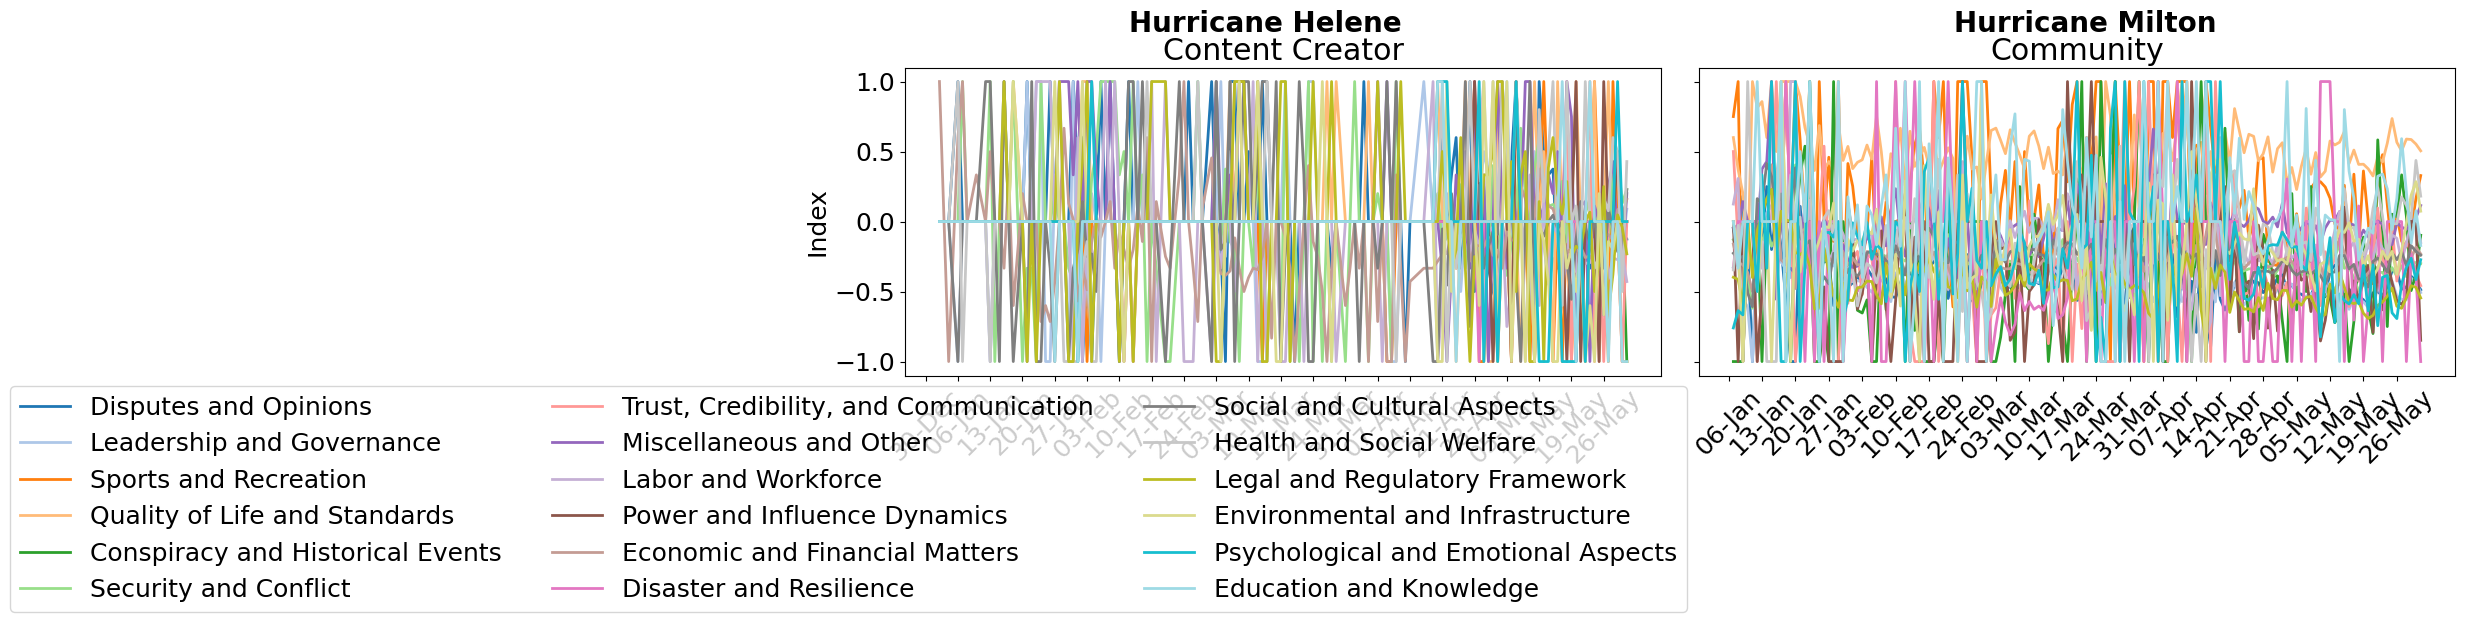

In [32]:
start_date = dt.date(2025, 1, 1)
end_date = dt.date(2025, 5, 31)

plot_ei_topic(
    df_transcripts_ei_topic[(df_transcripts_ei_topic.date >= start_date) & (df_transcripts_ei_topic.date <= end_date)],
    df_comments_ei_topic[(df_comments_ei_topic.date >= start_date) & (df_comments_ei_topic.date <= end_date)],
    topic_list,
    legend_cols=3
)

In [33]:
# Create weights from the EI topic dataframes
# The columns in df_transcripts_ei_topic are: date, ei_creator_{topic}
# The columns in df_comments_ei_topic are: date, ei_community_{topic}

# Get topics from the actual columns (excluding 'date' and 'other')
creator_ei_cols = [col for col in df_transcripts_ei_topic.columns if col.startswith('ei_creator_') and 'other' not in col.lower()]
community_ei_cols = [col for col in df_comments_ei_topic.columns if col.startswith('ei_community_') and 'other' not in col.lower()]

# Extract topic names from column names
creator_topics = [col.replace('ei_creator_', '') for col in creator_ei_cols]
community_topics = [col.replace('ei_community_', '') for col in community_ei_cols]

# Calculate weights based on absolute EI values (higher absolute EI = more emotional content = higher weight)
creator_weights = df_transcripts_ei_topic[['date'] + creator_ei_cols].copy()
community_weights = df_comments_ei_topic[['date'] + community_ei_cols].copy()

# Ensure date columns are datetime type
creator_weights['date'] = pd.to_datetime(creator_weights['date'])
community_weights['date'] = pd.to_datetime(community_weights['date'])

# Calculate percentage weights for each topic based on absolute EI values
for col in creator_ei_cols:
    topic = col.replace('ei_creator_', '')
    creator_weights[f'creator_{topic}_percent'] = creator_weights[col].abs()

for col in community_ei_cols:
    topic = col.replace('ei_community_', '')
    community_weights[f'community_{topic}_percent'] = community_weights[col].abs()

# Normalize to get percentages (sum to 1 for each row)
creator_percent_cols = [col for col in creator_weights.columns if col.endswith('_percent')]
community_percent_cols = [col for col in community_weights.columns if col.endswith('_percent')]

creator_weights[creator_percent_cols] = creator_weights[creator_percent_cols].div(
    creator_weights[creator_percent_cols].sum(axis=1).replace(0, 1), axis=0
)
community_weights[community_percent_cols] = community_weights[community_percent_cols].div(
    community_weights[community_percent_cols].sum(axis=1).replace(0, 1), axis=0
)

# Keep only date and percent columns for merging
creator_weights = creator_weights[['date'] + creator_percent_cols]
community_weights = community_weights[['date'] + community_percent_cols]

# Prepare df_epi_topic for merge - ensure date is datetime
df_epi_topic_merge = df_epi_topic.copy()
df_epi_topic_merge['date'] = pd.to_datetime(df_epi_topic_merge['date'])

# Merge datasets
epi_weights = pd.merge(df_epi_topic_merge, creator_weights, on='date', how='outer').fillna(0)
epi_weights = pd.merge(epi_weights, community_weights, on='date', how='outer').fillna(0)

# Get the list of topics that exist in both creator and community
common_topics = list(set(creator_topics) & set(community_topics))

# Calculate combined weights for each topic and normalize to sum to 1 across topics
for topic in common_topics:
    epi_weights[f'{topic}_combined_weight'] = (
        epi_weights[f'creator_{topic}_percent'] + epi_weights[f'community_{topic}_percent']
    )

# Normalize combined weights to sum to 1 per row
weight_cols = [f'{t}_combined_weight' for t in common_topics if f'{t}_combined_weight' in epi_weights.columns]
weight_sum = epi_weights[weight_cols].sum(axis=1).replace(0, 1)
for col in weight_cols:
    epi_weights[col] = epi_weights[col] / weight_sum

# Calculate weighted EPI as a proper weighted average
epi_weights['epi_weighted'] = 0.0
for topic in common_topics:
    if f'epi_{topic}' in epi_weights.columns and f'{topic}_combined_weight' in epi_weights.columns:
        epi_weights['epi_weighted'] += (
            epi_weights[f'epi_{topic}'] * epi_weights[f'{topic}_combined_weight']
        )

# No clipping needed - result is naturally in [-1, 1] range since weights sum to 1

In [34]:
# Calculate weighted EI for creator and community
epi_weights['ei_creator_weighted'] = 0.0
epi_weights['ei_community_weighted'] = 0.0

for topic in common_topics:
    # Weighted EI for creator using creator weights
    if f'ei_creator_{topic}' in epi_weights.columns and f'creator_{topic}_percent' in epi_weights.columns:
        epi_weights['ei_creator_weighted'] += (
            epi_weights[f'ei_creator_{topic}'] * epi_weights[f'creator_{topic}_percent']
        )
    
    # Weighted EI for community using community weights
    if f'ei_community_{topic}' in epi_weights.columns and f'community_{topic}_percent' in epi_weights.columns:
        epi_weights['ei_community_weighted'] += (
            epi_weights[f'ei_community_{topic}'] * epi_weights[f'community_{topic}_percent']
        )

# Results are naturally in [-1, 1] range since weights sum to 1

In [35]:
def plot_epi_topic_weighted(
    df: pd.DataFrame,
):

    df1 = deepcopy(df)

    # Convert 'date' column to datetime format
    df1["date"] = pd.to_datetime(df1["date"], format="%Y-%m-%d")

    plt.rcParams.update({"font.size": 20})

    # Create figure with a single subplot
    fig, ax1 = plt.subplots(
        1, 1, figsize=(20, 10), sharey=True
    )

    # --- Graph ---
    ax1.plot(
        df1["date"],
        df1["epi_weighted"],
        linewidth=4,
        color="r",
        label="Weighted EPI",
    )

    ax1.plot(
        df1["date"],
        df1["ei_creator_weighted"],
        linewidth=2,
        linestyle="--",
        color="blue",
        label="Creator EI (Weighted)",
    )

    ax1.plot(
        df1["date"],
        df1["ei_community_weighted"],
        linewidth=2,
        linestyle="-.",
        color="green",
        label="Community EI (Weighted)",
    )

    ax1.set_ylim(-1, 1)

    # Annoucement Tariffs (20 Jan - 26 Jan)
    ax1.axvspan(
        pd.to_datetime("2025-01-20"),
        pd.to_datetime("2025-01-26"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-01-23"), 0.84, "Initial Tariff\nAnnouncements", color="black", ha="center")

    # Imposition and Postponing of Tariffs (04 Mar - 06 Mar)
    ax1.axvspan(
        pd.to_datetime("2025-03-04"),
        pd.to_datetime("2025-03-06"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-03-02"), 0.84, "Tariffs\nPostponed", color="black", ha="center")

    # China retaliation (08 Mar - 12 Mar)
    # 200% Tariff Threat (12 Mar - 14 Mar)
    ax1.axvspan(
        pd.to_datetime("2025-03-10"),
        pd.to_datetime("2025-03-13"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-03-13"), 0.5, "China\nRetaliation\n& US Tariffs\nImposed", color="black", ha="center")

    # China Tariff Retaliation (2 Apr - 6 Apr)
    ax1.axvspan(
        pd.to_datetime("2025-04-02"),
        pd.to_datetime("2025-04-06"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-04-04"), 0.84, "Global Tariffs\n & China Retaliation", color="black", ha="center")

    # US China Tariff Threats (9 Apr - 11 Apr)
    ax1.axvspan(
        pd.to_datetime("2025-04-09"),
        pd.to_datetime("2025-04-12"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-04-12"), 0.6, "US-China\nTariff Threats", color="black", ha="center")

    # Tariff Relaxed (27 Apr - 04 May)
    ax1.axvspan(
        pd.to_datetime("2025-04-27"),
        pd.to_datetime("2025-05-04"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-04-30"), 0.55, "Tariffs\nRelaxed", color="black", ha="center")

    # Trade Deals and Tariff Rollbacks (05 May - 14 May)
    ax1.axvspan(
        pd.to_datetime("2025-05-05"),
        pd.to_datetime("2025-05-14"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-05-09"), 0.75, "Trade Deals\n & US-China\nTariff Rollbacks", color="black", ha="center")

    # Non-US Apple Tariff Threat (20 May - 25 May)
    ax1.axvspan(
        pd.to_datetime("2025-05-20"),
        pd.to_datetime("2025-05-25"),
        color="gray",
        alpha=0.3,
    )
    ax1.text(pd.to_datetime("2025-05-22"), 0.45, "Non-US\nManufactured Apple\nTariff Threat", color="black", ha="center")

    # Formatting
    week_start_dates = (
        df1["date"].dt.to_period("W").drop_duplicates().dt.start_time
    )  # Get start of each week
    ax1.set_xticks(week_start_dates)  # Set ticks at these dates
    ax1.set_xticklabels(
        week_start_dates.dt.strftime("%d-%b")
    )  # Format labels correctly
    plt.xticks(rotation=360)  # Rotate x-ticks for better readability

    # add horizontal line at y=0
    ax1.axhline(0, color="black", linewidth=2, linestyle="--")

    # Remove x-axis label
    ax1.set_ylabel("Index")

    # Rotate x-axis labels
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # Add legend
    ax1.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        frameon=False,
    )

    # Adjust layout to ensure everything fits
    plt.tight_layout(rect=[0, 0, 1, 1])

    # Show plot
    plt.show()

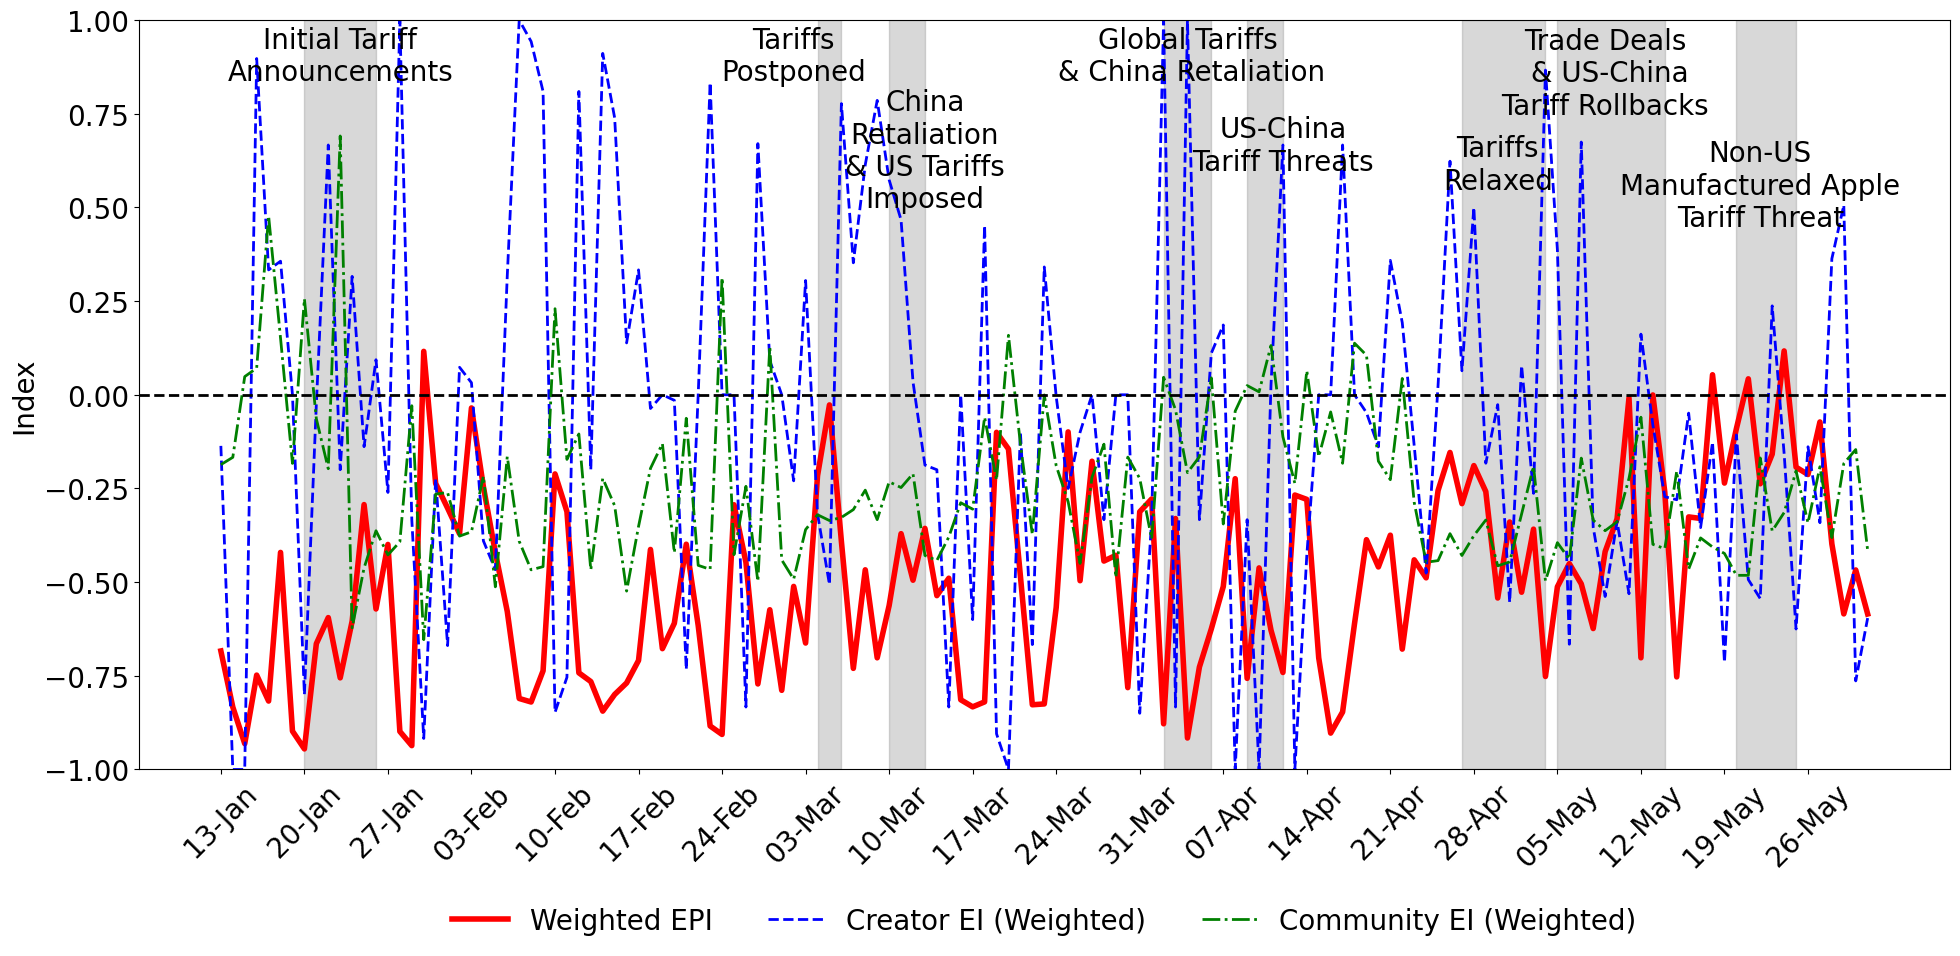

In [36]:
plot_epi_topic_weighted(
    epi_weights[(epi_weights.date >= pd.to_datetime("2025-01-13")) & (epi_weights.date <= pd.to_datetime(end_date))]
)

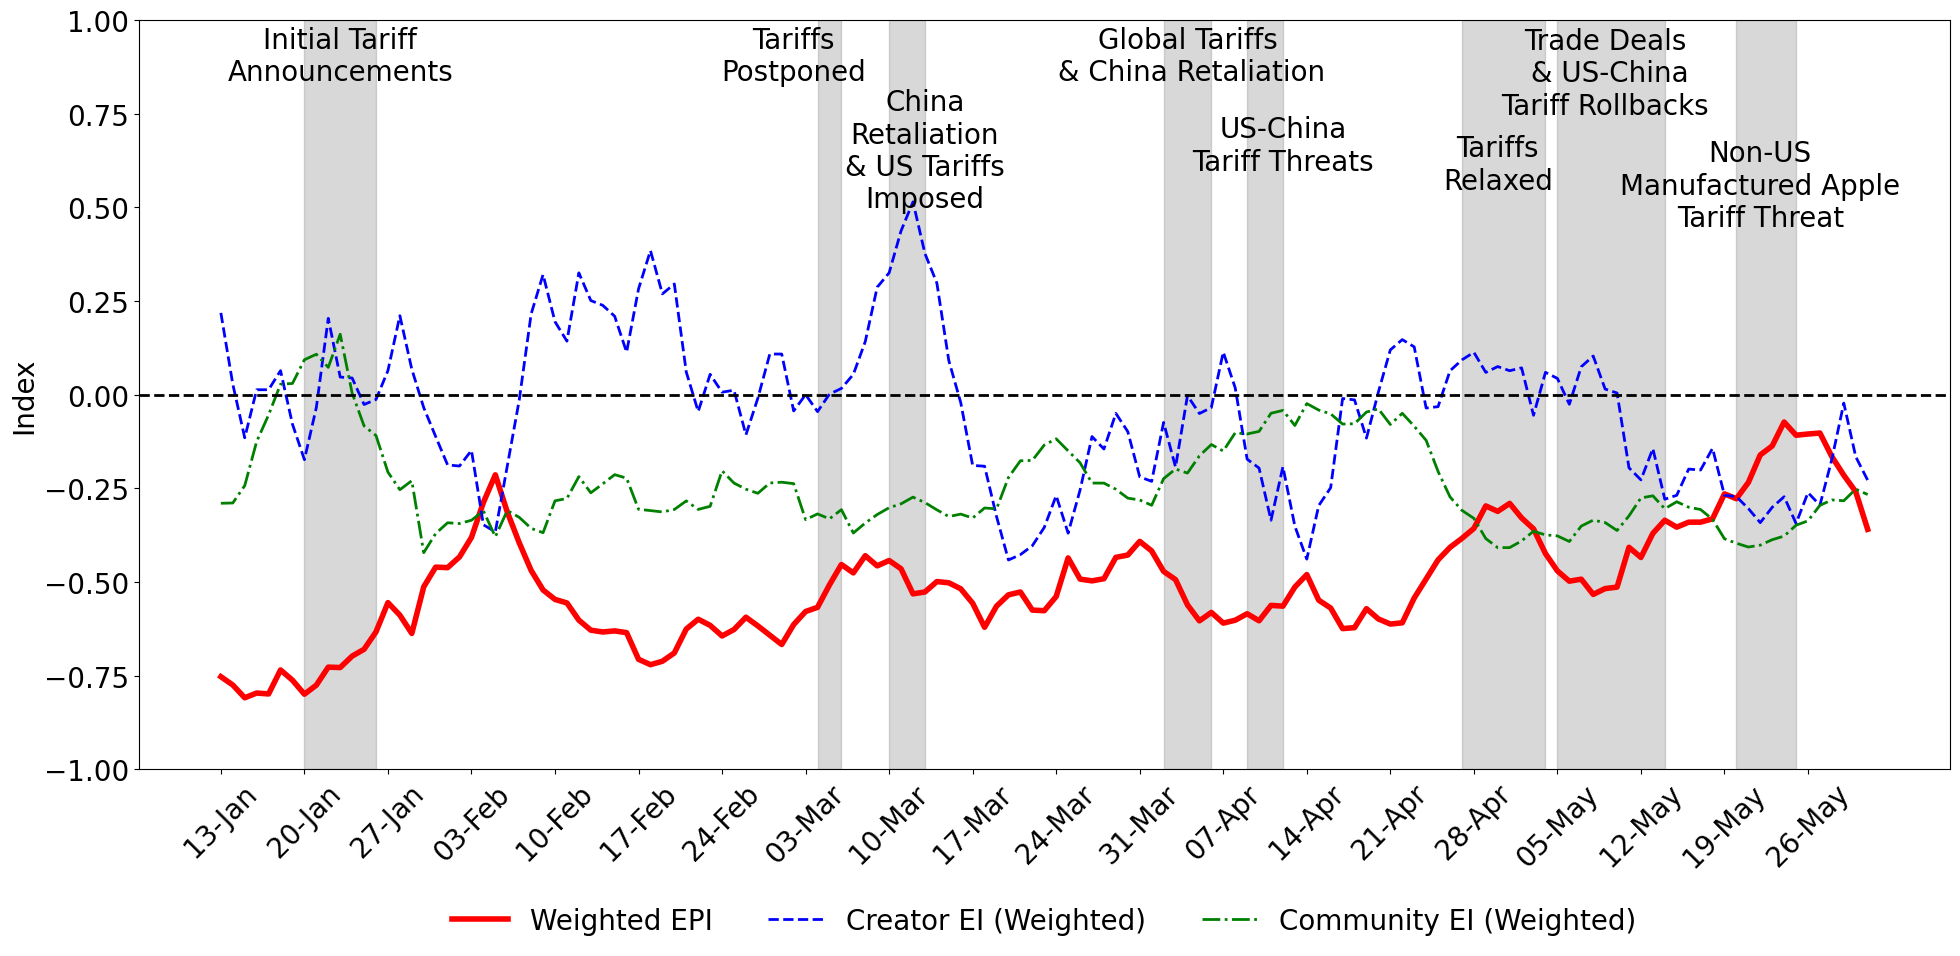

In [37]:
# Create rolling 7-day window average for epi_weights
epi_weights_MA7 = epi_weights.copy()
epi_weights_MA7['epi_weighted'] = epi_weights['epi_weighted'].rolling(window=7).mean()
epi_weights_MA7['ei_creator_weighted'] = epi_weights['ei_creator_weighted'].rolling(window=7).mean()
epi_weights_MA7['ei_community_weighted'] = epi_weights['ei_community_weighted'].rolling(window=7).mean()

plot_epi_topic_weighted(
    epi_weights_MA7[(epi_weights_MA7.date >= pd.to_datetime("2025-01-13")) & (epi_weights_MA7.date <= pd.to_datetime(end_date))]
)

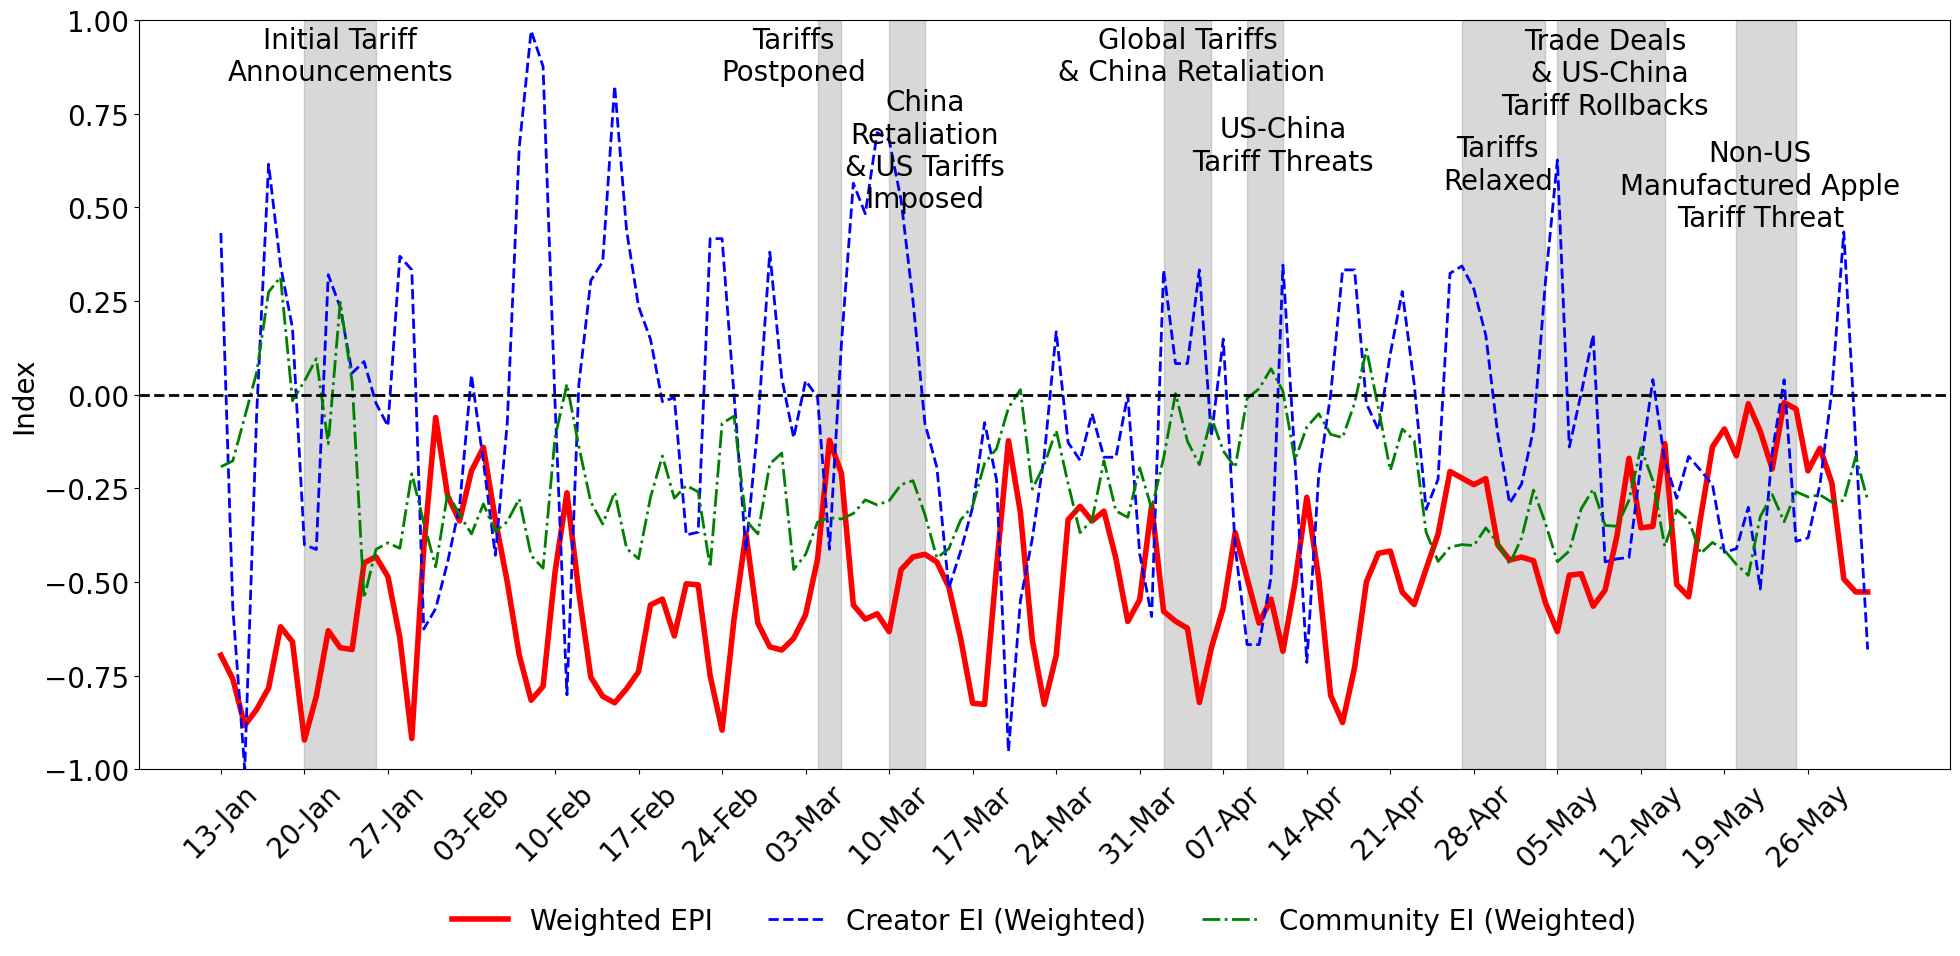

In [38]:
# Create rolling 2-day window average for epi_weights
epi_weights_MA2 = epi_weights.copy()
epi_weights_MA2['epi_weighted'] = epi_weights['epi_weighted'].rolling(window=2).mean()
epi_weights_MA2['ei_creator_weighted'] = epi_weights['ei_creator_weighted'].rolling(window=2).mean()
epi_weights_MA2['ei_community_weighted'] = epi_weights['ei_community_weighted'].rolling(window=2).mean()

plot_epi_topic_weighted(
    epi_weights_MA2[(epi_weights_MA2.date >= pd.to_datetime("2025-01-13")) & (epi_weights_MA2.date <= pd.to_datetime(end_date))]
)

## Export EPI Data to JSON

In [47]:
# Export EPI and topic-weighted EPI data to JSON for use in financial modelling

import json

# Prepare df_epi for export (main EPI with date, ei_creator, ei_community, epi)
df_epi_export = df_epi.copy()
df_epi_export['date'] = df_epi_export['date'].dt.strftime('%Y-%m-%d')

# Prepare epi_weights for export (topic-weighted EPIs)
# Select relevant columns: date, epi_weighted, and topic-specific epi columns
epi_cols = ['date', 'epi_weighted'] + \
    [col for col in epi_weights.columns if (col.startswith('epi_') or col.startswith('ei_')) and col != 'epi_weighted']
df_epi_topic_export = epi_weights[epi_cols].copy()
df_epi_topic_export['date'] = pd.to_datetime(df_epi_topic_export['date']).dt.strftime('%Y-%m-%d')

# Combine both dataframes into a single export
# Merge on date to create a comprehensive EPI dataset
df_epi_combined = pd.merge(
    df_epi_export,
    df_epi_topic_export,
    on='date',
    how='outer'
).sort_values('date')


In [48]:
# Export to JSON
output_path = 'data/epi_data.json'
df_epi_combined.to_json(output_path, orient='records', date_format='iso', indent=2)

print(f"EPI data exported to {output_path}")
print(f"Columns: {df_epi_combined.columns.tolist()}")
print(f"Date range: {df_epi_combined['date'].min()} to {df_epi_combined['date'].max()}")
print(f"Total records: {len(df_epi_combined)}")

EPI data exported to data/epi_data.json
Columns: ['date', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'ei_creator_Disputes and Opinions', 'ei_creator_Leadership and Governance', 'ei_creator_Sports and Recreation', 'ei_creator_Quality of Life and Standards', 'ei_creator_Conspiracy and Historical Events', 'ei_creator_Security and Conflict', 'ei_creator_Trust, Credibility, and Communication', 'ei_creator_Miscellaneous and Other', 'ei_creator_Labor and Workforce', 'ei_creator_Power and Influence Dynamics', 'ei_creator_Economic and Financial Matters', 'ei_creator_Disaster and Resilience', 'ei_creator_Social and Cultural Aspects', 'ei_creator_Health and Social Welfare', 'ei_creator_Legal and Regulatory Framework', 'ei_creator_Environmental and Infrastructure', 'ei_creator_Psychological and Emotional Aspects', 'ei_creator_Education and Knowledge', 'ei_community_Disputes and Opinions', 'ei_community_Leadership and Governance', 'ei_community_Sports and Recreation', 'ei_community_Qualit